In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("../data/raw/synthetic_it_support_tickets.csv")

print(df.shape)

df.head()

(100000, 20)


,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password is incorrect.,Sorry to hear you're having trouble accessing your account. We will look into this and get back to you within the next 48 hours.,Reset account credentials and confirmed successful login.,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is reviewing this and will follow up within 24 hours.,Ticket closed without further action after no response from the customer.,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my changes.,Thanks for reporting this bug. We will look into this and get back to you within the next 48 hours.,NaN,NaN,0,neutral,3,0,android,MEA
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password is incorrect.,Sorry to hear you're having trouble accessing your account. Our team is reviewing this and will follow up within 24 hours.,NaN,NaN,0,positive,5,1,android,LATAM
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the plan I selected.,Thanks for reaching out about the billing issue. We will look into this and get back to you within the next 48 hours.,Adjusted the invoice and issued a refund where applicable.,61.32,0,very_negative,2,0,web,NaN


In [3]:
print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ticket_id              100000 non-null  str    
 1   created_at             100000 non-null  str    
 2   customer_id            100000 non-null  str    
 3   customer_segment       100000 non-null  str    
 4   channel                100000 non-null  str    
 5   product_area           100000 non-null  str    
 6   issue_type             100000 non-null  str    
 7   priority               100000 non-null  str    
 8   status                 100000 non-null  str    
 9   sla_plan               100000 non-null  str    
 10  initial_message        100000 non-null  str    
 11  agent_first_reply      100000 non-null  str    
 12  resolution_summary     60113 non-null   str    
 13  resolution_time_hours  60113 non-null   float64
 14  reopened               10000

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ticket_id,100000,100000,TCKT_000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,100000,99959,2023-06-29T22:03:45,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,100000,9999,CUST_07153,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,100000,5,small_business,20203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,100000,5,phone_transcript,20133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_area,100000,7,mobile_app,14432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
issue_type,100000,8,how_to,12739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,100000,4,low,39735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,100000,5,resolved,50131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sla_plan,100000,3,standard,60066,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing = pd.DataFrame({

    "Missing Values": df.isnull().sum(),

    "Percentage": round(df.isnull().mean()*100,2)

})

missing.sort_values(

    by="Percentage",

    ascending=False

)

,Missing Values,Percentage
resolution_summary,39887,39.89
resolution_time_hours,39887,39.89
region,19997,20.00
ticket_id,0,0.00
customer_segment,0,0.00
customer_id,0,0.00
created_at,0,0.00
channel,0,0.00
status,0,0.00
product_area,0,0.00


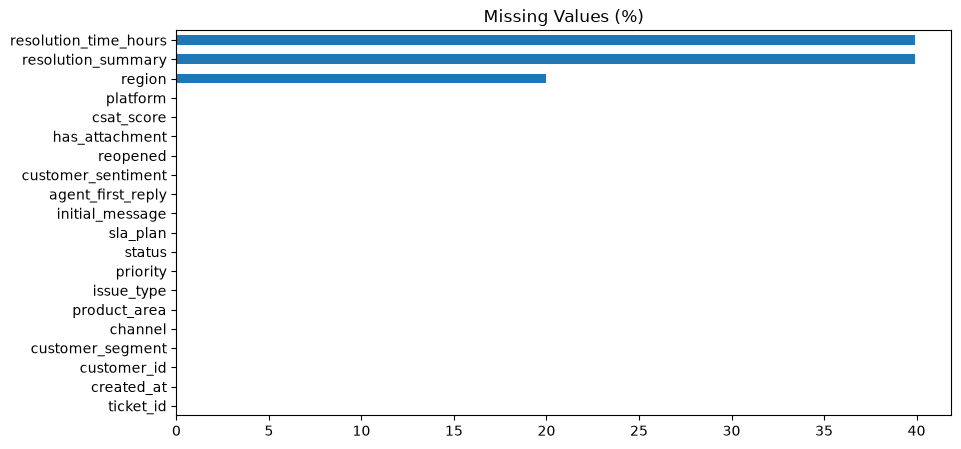

In [6]:
plt.figure(figsize=(10,5))

missing["Percentage"].sort_values().plot(kind="barh")

plt.title("Missing Values (%)")

plt.show()

In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [8]:
df = df.drop_duplicates()

print(df.shape)

(100000, 20)


In [9]:
df["created_at"] = pd.to_datetime(df["created_at"])

In [10]:
df.dtypes

ticket_id                           str
created_at               datetime64[us]
customer_id                         str
customer_segment                    str
channel                             str
product_area                        str
issue_type                          str
priority                            str
status                              str
sla_plan                            str
initial_message                     str
agent_first_reply                   str
resolution_summary                  str
resolution_time_hours           float64
reopened                          int64
customer_sentiment                  str
csat_score                        int64
has_attachment                    int64
platform                            str
region                              str
dtype: object

In [11]:
df["region"] = df["region"].fillna("Unknown")

In [12]:
df.isnull().sum()

ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary       39887
resolution_time_hours    39887
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                       0
dtype: int64

In [13]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+","",text)

    text = re.sub(r"\s+"," ",text)

    text = text.strip()

    return text

In [14]:
df["message_length"] = df["initial_message"].str.len()

df["word_count"] = df["initial_message"].str.split().str.len()

In [15]:
df["initial_message"] = df["initial_message"].apply(clean_text)

df["agent_first_reply"] = df["agent_first_reply"].apply(clean_text)

df["resolution_summary"] = df["resolution_summary"].apply(

    lambda x: clean_text(x) if pd.notnull(x) else x

)

In [16]:
df[

    [

        "initial_message",

        "agent_first_reply",

        "resolution_summary"

    ]

].sample(5)

,initial_message,agent_first_reply,resolution_summary
63387,my 2fa code is not working when i try to sign in.,sorry to hear you're having trouble accessing your account. our team is reviewing this and will follow up within 24 hours.,NaN
22296,i noticed a suspicious login on my account.,we take security very seriously. we will look into this and get back to you within the next 48 hours.,"investigated logs, mitigated the issue, and updated security settings."
11741,the api integration page is very slow and takes a long time to load.,we understand performance issues can be frustrating. we will look into this and get back to you within the next 48 hours.,optimized queries and increased resource allocation.
98459,i have a general question about my account.,thanks for contacting support. our team is reviewing this and will follow up within 24 hours.,ticket closed without further action after no response from the customer.
63281,i am seeing an error message when i click on data export.,thanks for reporting this bug. we will look into this and get back to you within the next 48 hours.,patched the bug and deployed a fix to production.


In [17]:
# Message Length
df["message_length"] = df["initial_message"].str.len()

# Word Count
df["word_count"] = df["initial_message"].str.split().str.len()

# Resolved Flag
df["is_resolved"] = df["resolution_time_hours"].notna().astype(int)

In [18]:
df[
    [
        "message_length",
        "word_count",
        "is_resolved"
    ]
].head()

,message_length,word_count,is_resolved
0,58,11,1
1,43,8,1
2,53,9,0
3,58,11,0
4,63,11,1


In [19]:
target_columns = [

    "issue_type",

    "priority",

    "customer_sentiment",

    "resolution_time_hours"

]

for col in target_columns:

    print("="*50)

    print(col)

    print(df[col].value_counts(dropna=False).head(20))

    print()

issue_type
issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64

priority
priority
low       39735
medium    35313
high      19865
urgent     5087
Name: count, dtype: int64

customer_sentiment
customer_sentiment
neutral          32634
negative         26015
very_negative    16437
positive         16242
very_positive     8672
Name: count, dtype: int64

resolution_time_hours
resolution_time_hours
NaN      39887
13.65       23
22.38       23
6.95        23
17.48       23
8.36        23
10.81       22
11.45       22
5.11        22
14.74       22
22.31       21
23.66       21
4.89        21
12.47       21
13.70       21
11.56       20
12.90       20
6.50        20
8.75        20
15.14       20
Name: count, dtype: int64



In [20]:
categorical_columns = [

    "customer_segment",

    "channel",

    "product_area",

    "issue_type",

    "priority",

    "status",

    "sla_plan",

    "platform",

    "region"

]

In [21]:
for col in categorical_columns:

    print("="*50)

    print(col)

    print(df[col].value_counts())

    print()

customer_segment
customer_segment
small_business    20203
individual        20033
enterprise        20030
education         19958
non_profit        19776
Name: count, dtype: int64

channel
channel
phone_transcript    20133
email               20088
in_app              19982
web_form            19965
chat                19832
Name: count, dtype: int64

product_area
product_area
mobile_app             14432
login_auth             14381
api_integration        14350
billing                14289
data_export            14262
analytics_dashboard    14187
notifications          14099
Name: count, dtype: int64

issue_type
issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64

priority
priority
low       39735
medium    35313
high      19865
urgent     5087
Name: count, dtype: int64

status
status
resolved  

In [22]:
numerical = [

    "resolution_time_hours",

    "csat_score"

]

In [23]:
print(df.shape)

print(df.isnull().sum())

(100000, 23)
ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary       39887
resolution_time_hours    39887
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                       0
message_length               0
word_count                   0
is_resolved                  0
dtype: int64


In [24]:
df.sample(10, random_state=42)

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region,message_length,word_count,is_resolved
75721,TCKT_075722,2024-02-02 23:07:49,CUST_03968,non_profit,phone_transcript,notifications,other,high,resolved,standard,i need help but i'm not sure which category this fits in.,thanks for contacting support. we are prioritizing this and will update you as soon as possible.,provided general guidance and confirmed the issue was resolved.,6.47,0,neutral,4,0,web,LATAM,57,12,1
80184,TCKT_080185,2025-11-16 19:07:23,CUST_05746,individual,in_app,login_auth,account_access,urgent,resolved,standard,my account was locked after multiple failed login attempts.,sorry to hear you're having trouble accessing your account. this has been escalated to our on-call team for immediate attention.,reset account credentials and confirmed successful login.,5.10,0,neutral,4,0,android,MEA,59,9,1
19864,TCKT_019865,2025-12-02 22:15:37,CUST_04592,small_business,phone_transcript,api_integration,account_access,low,resolved,platinum,i cannot log in; the system says my password is incorrect.,sorry to hear you're having trouble accessing your account. we will look into this and get back to you within the next 48 hours.,reset account credentials and confirmed successful login.,49.80,0,negative,2,1,web,MEA,58,11,1
76699,TCKT_076700,2024-06-22 04:06:43,CUST_04204,individual,chat,data_export,bug,low,resolved,standard,i am seeing an error message when i click on data export.,thanks for reporting this bug. we will look into this and get back to you within the next 48 hours.,patched the bug and deployed a fix to production.,49.33,0,neutral,0,0,api_client,EU,57,12,1
92991,TCKT_092992,2024-08-16 03:33:46,CUST_03044,enterprise,web_form,mobile_app,account_access,low,on_hold,standard,my 2fa code is not working when i try to sign in.,sorry to hear you're having trouble accessing your account. we will look into this and get back to you within the next 48 hours.,NaN,NaN,0,positive,5,0,ios,MEA,49,12,0
76434,TCKT_076435,2025-11-15 17:45:27,CUST_06456,education,phone_transcript,billing,bug,low,in_progress,gold,the billing feature is not saving my changes.,thanks for reporting this bug. we will look into this and get back to you within the next 48 hours.,NaN,NaN,0,positive,5,1,android,EU,45,8,0
84004,TCKT_084005,2023-09-11 01:47:28,CUST_08153,education,chat,api_integration,account_access,high,open,standard,i cannot log in; the system says my password is incorrect.,sorry to hear you're having trouble accessing your account. we are prioritizing this and will update you as soon as possible.,NaN,NaN,0,negative,2,0,api_client,MEA,58,11,0
80917,TCKT_080918,2023-04-16 17:21:33,CUST_00534,non_profit,web_form,mobile_app,other,low,closed_no_action,gold,i need help but i'm not sure which category this fits in.,thanks for contacting support. we will look into this and get back to you within the next 48 hours.,ticket closed without further action after no response from the customer.,142.77,0,neutral,0,1,web,APAC,57,12,1
60767,TCKT_060768,2023-11-17 04:53:26,CUST_02880,enterprise,web_form,data_export,feature_request,high,resolved,gold,can you add an option to customize data export?,thanks for your feature suggestion. we are prioritizing this and will update you as soon as possible.,captured the request and added it to the product backlog.,2.24,0,positive,4,0,desktop_app,MEA,47,9,1
50074,TCKT_050075,2024-12-28 06:45:17,CUST_09710,small_business,in_app,api_integration,billing_problem,urgent,resolved,standard,i downgraded my plan but i am still being billed for the higher tier.,thanks for reaching out about the billing issue. this has been escalated to our on-call team for immediate attention.,adjusted the invoice and issued a refund where applicable.,3.56,1,very_positive,5,1,ios,EU,69,14,1


In [25]:
# Save Complete Dataset

df.to_csv(

    "../data/processed/clean_customer_support_dataset.csv",

    index=False

)

# Save Only Resolved Tickets

resolved_df = df[df["is_resolved"] == 1]

resolved_df.to_csv(

    "../data/processed/resolved_tickets.csv",

    index=False

)

print("Datasets Saved Successfully")

Datasets Saved Successfully
